# Single PIREP Satellite Pipeline Demo
Walk through the full satellite data pipeline for one PIREP:
1. Load a SEV+ PIREP from the NEXRAD project's clean CSVs
2. Fetch 9 hourly GOES-16 satellite images (bands 8,9,10,13,14,15)
3. Project onto CONUS grid, smooth, and crop 128x128 around the PIREP
4. Save as .npz model input
5. Visualize the result

In [1]:
import sys, os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from goes2go import GOES

# Add src/ to path
sys.path.insert(0, os.path.abspath('.'))
import satellite as sat
from consts import GRID_RANGE, MAP_RANGE, BANDS, CROP_SIZE, NUM_FRAMES
from utils.convert import convert_coord
from fetch_satellite_for_pireps import get_crop_indices, fetch_frames_for_pirep

print('Imports successful')

Imports successful


## Step 1: Load a PIREP
Pick a recent SEV PIREP from the NEXRAD project's clean data (must be 2017+ for GOES-16).

In [2]:
# Load PIREPs from NEXRAD project
nexrad_base = os.path.abspath('../../NEXRADTurbulencePrediction')
pirep_csv = os.path.join(nexrad_base, 'pireps/clean_pirep_data/2024/03_turb_pireps.csv')
pireps_df = pd.read_csv(pirep_csv)
print(f'Loaded {len(pireps_df)} PIREPs')
pireps_df.head()

Loaded 525 PIREPs


,URGENT,AIRCRAFT,REPORT,TURBULENCE,PRODUCT_ID,FL,LAT,LON,datetime,turbulence_intensity,Plane Weight
0,T,B737,LAS UUA /OV LAS/TM 0145/FL380/TP B737/TB SEV C...,SEV CHOP,NaN,38000.0,36.071900,-115.163400,2024-03-01 01:45:00,5.0,M
1,T,B737,LAS UUA /OV LAS /TM 0145/FL380/TP B737/TB SEV ...,SEV CHOP 400-380,NaN,38000.0,36.071900,-115.163400,2024-03-01 01:45:00,5.0,M
2,T,B737,LAS UUA /OV LAS /TM 0146/FL400/TP B737/TB SEV ...,SEV CHOP 400-400,NaN,40000.0,36.071900,-115.163400,2024-03-01 01:46:00,5.0,M
3,F,C25B,BZN UA /OV BZN025015/TM 0155/FL110/TP C25B/TB SEV,SEV,NaN,11000.0,46.014655,-111.009301,2024-03-01 01:55:00,5.0,U
4,T,C25B,BZN UUA /OV BZN 025015/TM 0155/FL110/TP C25B/T...,SEV,NaN,11000.0,46.014655,-111.009301,2024-03-01 01:55:00,5.0,U


In [3]:
# Pick the first PIREP
pirep = pireps_df.iloc[0]
pirep_dt = datetime.fromisoformat(pirep['datetime'])
pirep_lat = pirep['LAT']
pirep_lon = pirep['LON']

print(f'PIREP: {pirep["TURBULENCE"]}')
print(f'  Time: {pirep_dt}')
print(f'  Location: ({pirep_lat:.2f}, {pirep_lon:.2f})')
print(f'  Flight Level: {pirep["FL"]}')
print(f'  Intensity: {pirep["turbulence_intensity"]}')
print(f'  Aircraft: {pirep["AIRCRAFT"]}')

PIREP: SEV CHOP
  Time: 2024-03-01 01:45:00
  Location: (36.07, -115.16)
  Flight Level: 38000.0
  Intensity: 5.0
  Aircraft: B737


## Step 2: Compute crop bounds

In [4]:
crop = get_crop_indices(pirep_lat, pirep_lon)
if crop is None:
    print('ERROR: PIREP location out of CONUS grid bounds')
else:
    row_start, row_end, col_start, col_end = crop
    print(f'Crop bounds: rows [{row_start}:{row_end}], cols [{col_start}:{col_end}]')
    print(f'Crop size: {row_end - row_start} x {col_end - col_start}')

Crop bounds: rows [616:744], cols [545:673]
Crop size: 128 x 128


## Step 3: Fetch a single satellite image
Test fetching one frame before doing all 9.

In [5]:
goes_sat = GOES(satellite=16, product='ABI', domain='C')

print(f'Fetching satellite image near {pirep_dt}...')
data = sat.fetch(pirep_dt, goes_sat)
print(f'Got satellite data with variables: {list(data.data_vars)[:10]}...')

# Calculate coordinates
lat_grid, lon_grid = sat.calculate_coordinates(data)
print(f'Lat range: [{np.nanmin(lat_grid):.1f}, {np.nanmax(lat_grid):.1f}]')
print(f'Lon range: [{np.nanmin(lon_grid):.1f}, {np.nanmax(lon_grid):.1f}]')

Fetching satellite image near 2024-03-01 01:45:00...
Got satellite data with variables: ['CMI_C01', 'DQF_C01', 'CMI_C02', 'DQF_C02', 'CMI_C03', 'DQF_C03', 'CMI_C04', 'DQF_C04', 'CMI_C05', 'DQF_C05']...
Lat range: [14.6, 56.6]
Lon range: [-151.7, -52.9]


In [6]:
# Extract bands
band_data = sat.fetch_bands(data, BANDS)
print(f'Band data shape: {band_data.shape}')
print(f'Bands: {BANDS}')

Band data shape: (1, 1500, 2500, 6)
Bands: [8, 9, 10, 13, 14, 15]


In [7]:
# Project onto grid
projected = sat.project(lat_grid, lon_grid, band_data.values)
print(f'Projected shape: {projected.shape}')

# Smooth
smoothed = sat.smooth(projected)
print(f'Smoothed shape: {smoothed.shape}')

# Crop
cropped = smoothed[0, row_start:row_end, col_start:col_end, :]
print(f'Cropped shape: {cropped.shape}')
print(f'NaN fraction: {np.isnan(cropped).mean():.3f}')
print(f'Zero fraction: {(cropped == 0).mean():.3f}')

Projected shape: (1, 1500, 2500, 6)
Smoothed shape: (1, 1500, 2500, 6)
Cropped shape: (128, 128, 6)
NaN fraction: 0.000
Zero fraction: 0.000


## Step 4: Fetch all 9 frames

In [8]:
print(f'Fetching 9 hourly frames ending at {pirep_dt}...')
print(f'Time range: {pirep_dt - timedelta(hours=8)} to {pirep_dt}')
print()

frames = fetch_frames_for_pirep(pirep_dt, pirep_lat, pirep_lon, goes_sat)

if frames is not None:
    print(f'\nFrames shape: {frames.shape}')
    print(f'dtype: {frames.dtype}')
    print(f'Memory: {frames.nbytes / 1024 / 1024:.1f} MB')
    for i in range(NUM_FRAMES):
        t = pirep_dt - timedelta(hours=NUM_FRAMES - 1 - i)
        nonzero = (frames[i] != 0).mean()
        print(f'  Frame {i} ({t}): {nonzero*100:.1f}% non-zero')
else:
    print('ERROR: Failed to fetch frames')

Fetching 9 hourly frames ending at 2024-03-01 01:45:00...
Time range: 2024-02-29 17:45:00 to 2024-03-01 01:45:00


Frames shape: (9, 128, 128, 6)
dtype: float32
Memory: 3.4 MB
  Frame 0 (2024-02-29 17:45:00): 100.0% non-zero
  Frame 1 (2024-02-29 18:45:00): 100.0% non-zero
  Frame 2 (2024-02-29 19:45:00): 100.0% non-zero
  Frame 3 (2024-02-29 20:45:00): 100.0% non-zero
  Frame 4 (2024-02-29 21:45:00): 100.0% non-zero
  Frame 5 (2024-02-29 22:45:00): 100.0% non-zero
  Frame 6 (2024-02-29 23:45:00): 100.0% non-zero
  Frame 7 (2024-03-01 00:45:00): 100.0% non-zero
  Frame 8 (2024-03-01 01:45:00): 100.0% non-zero


## Step 5: Save as model input

In [9]:
output_path = 'single_pirep_satellite.npz'
np.savez_compressed(
    output_path,
    images=frames,
    turb_intensity=pirep['turbulence_intensity'],
    lat=pirep_lat,
    lon=pirep_lon,
    fl=pirep['FL'],
    datetime=str(pirep['datetime']),
)
file_size = os.path.getsize(output_path)
print(f'Saved to {output_path} ({file_size / 1024:.1f} KB)')

# Verify by loading it back
loaded = np.load(output_path)
print(f'\nLoaded back:')
print(f'  images shape: {loaded["images"].shape}')
print(f'  turb_intensity: {loaded["turb_intensity"]}')
print(f'  lat: {loaded["lat"]}, lon: {loaded["lon"]}')
print(f'  FL: {loaded["fl"]}')
print(f'  datetime: {loaded["datetime"]}')

Saved to single_pirep_satellite.npz (1134.2 KB)

Loaded back:
  images shape: (9, 128, 128, 6)
  turb_intensity: 5.0
  lat: 36.0719, lon: -115.1634
  FL: 38000.0
  datetime: 2024-03-01 01:45:00


## Step 6: Visualize

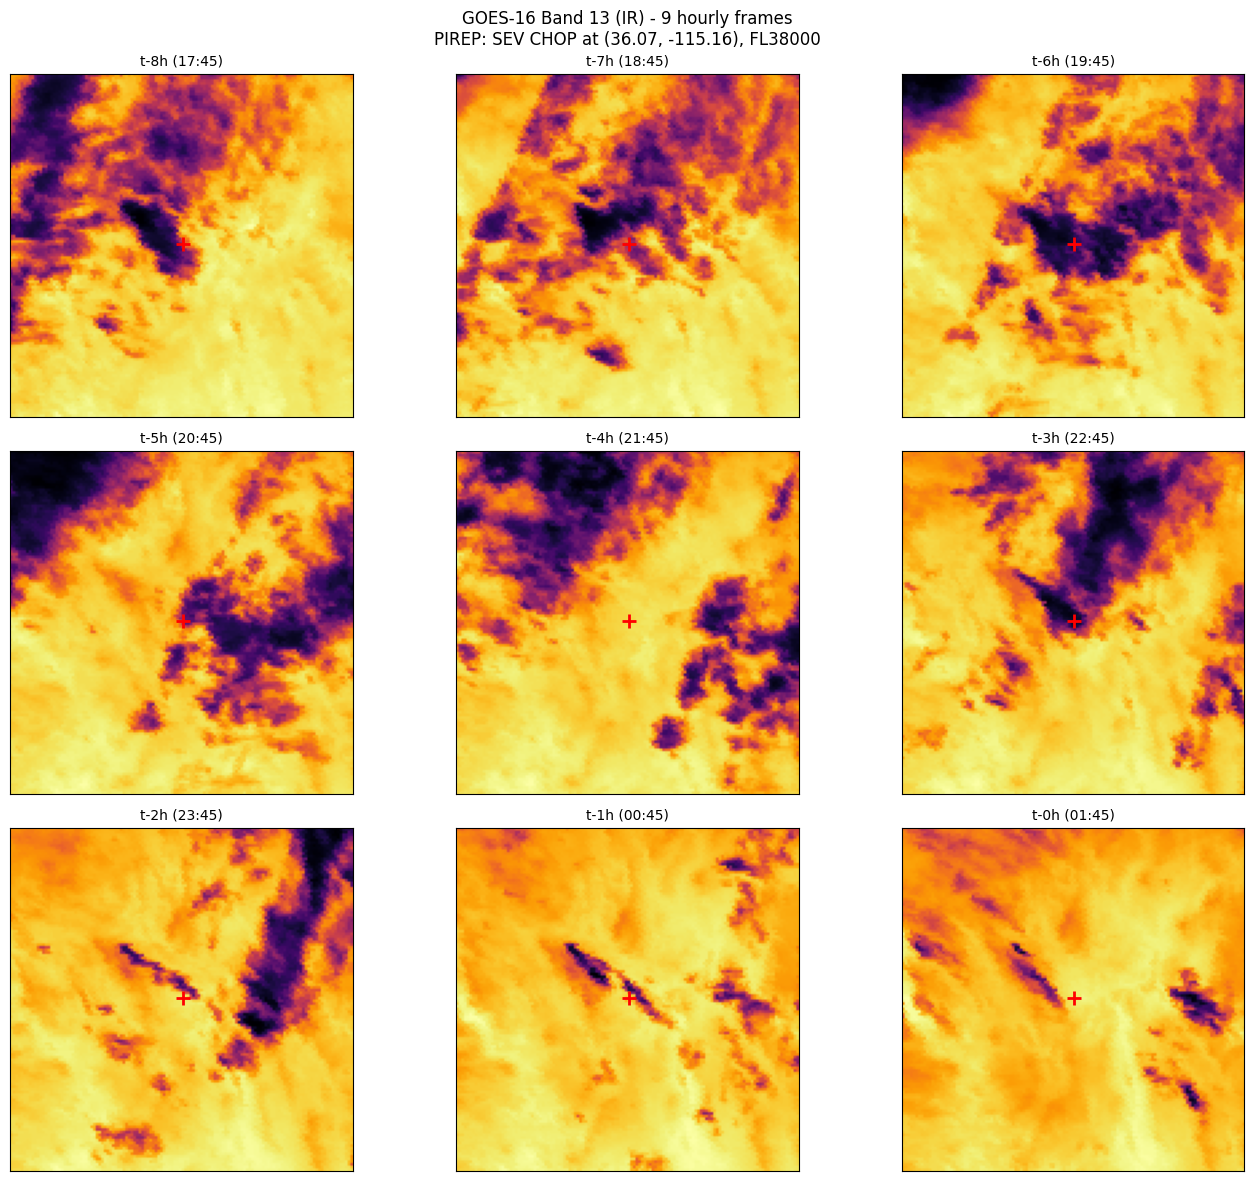

Saved visualization to single_pirep_satellite_vis.png


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
fig.suptitle(f'GOES-16 Band 13 (IR) - 9 hourly frames\n'
             f'PIREP: {pirep["TURBULENCE"]} at ({pirep_lat:.2f}, {pirep_lon:.2f}), FL{int(pirep["FL"])}',
             fontsize=12)

# Band 13 is index 3 in our BANDS list [8,9,10,13,14,15]
band_idx = 3

for i in range(NUM_FRAMES):
    ax = axes[i // 3][i % 3]
    t = pirep_dt - timedelta(hours=NUM_FRAMES - 1 - i)
    im = ax.imshow(frames[i, :, :, band_idx], cmap='inferno', origin='lower')
    ax.set_title(f't-{NUM_FRAMES - 1 - i}h ({t.strftime("%H:%M")})', fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    # Mark PIREP center
    ax.plot(CROP_SIZE // 2, CROP_SIZE // 2, 'r+', markersize=10, markeredgewidth=2)

plt.tight_layout()
plt.savefig('single_pirep_satellite_vis.png', dpi=150)
plt.show()
print('Saved visualization to single_pirep_satellite_vis.png')

## Step 7: Build a feature tensor (what the model sees)
Convert to PyTorch format matching the dataloader.

In [11]:
import torch

# Reorder from (9, 128, 128, 6) to (9, 6, 128, 128) for PyTorch
images_torch = torch.tensor(frames.transpose(0, 3, 1, 2), dtype=torch.float32)
images_torch = torch.nan_to_num(images_torch, nan=0.0)
label = int(pirep['turbulence_intensity'])

print(f'Feature tensor shape: {images_torch.shape}')
print(f'  (seq_len={NUM_FRAMES}, bands={len(BANDS)}, H={CROP_SIZE}, W={CROP_SIZE})')
print(f'Memory: {images_torch.element_size() * images_torch.nelement() / 1024 / 1024:.1f} MB')
print(f'Label (turbulence intensity): {label}')
print(f'\nThis (feature_tensor, label) pair is one training sample for the ConvLSTM model.')

Feature tensor shape: torch.Size([9, 6, 128, 128])
  (seq_len=9, bands=6, H=128, W=128)
Memory: 3.4 MB
Label (turbulence intensity): 5

This (feature_tensor, label) pair is one training sample for the ConvLSTM model.
